In [1]:
import pandas as pd
import numpy as np


nav    = pd.read_csv('data/raw/02_nav_history.csv')
master = pd.read_csv('data/raw/01_fund_master.csv')


nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])


nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()


results = []

for code, grp in nav.groupby('amfi_code'):
    returns = grp['daily_return'].dropna()
    
    var_95  = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    
    results.append({
        'amfi_code'             : code,
        'num_obs'               : len(returns),
        'mean_daily_return_pct' : round(returns.mean() * 100, 4),
        'std_daily_return_pct'  : round(returns.std()  * 100, 4),
        'VaR_95_pct'            : round(var_95  * 100, 4),
        'CVaR_95_pct'           : round(cvar_95 * 100, 4),
    })

df_var = pd.DataFrame(results)

keep   = master[['amfi_code','scheme_name','category','risk_category']].drop_duplicates('amfi_code')
df_var = df_var.merge(keep, on='amfi_code', how='left')


df_var = df_var[['amfi_code','scheme_name','category','risk_category',
                 'num_obs','mean_daily_return_pct','std_daily_return_pct',
                 'VaR_95_pct','CVaR_95_pct']]


df_var.to_csv('reports/var_cvar_report.csv', index=False)


print("✅ VaR & CVaR computed for", len(df_var), "funds\n")
print(df_var[['scheme_name','VaR_95_pct','CVaR_95_pct','risk_category']]
      .sort_values('VaR_95_pct')
      .to_string(index=False))

✅ VaR & CVaR computed for 40 funds

                                          scheme_name  VaR_95_pct  CVaR_95_pct   risk_category
            SBI Small Cap Fund - Direct Plan - Growth     -2.6859      -3.2384       Very High
               Axis Small Cap Fund - Regular - Growth     -2.6188      -3.1667       Very High
               ABSL Small Cap Fund - Regular - Growth     -2.6021      -3.2459       Very High
       Nippon India Small Cap Fund - Regular - Growth     -2.5438      -3.2304       Very High
           SBI Small Cap Fund - Regular Plan - Growth     -2.4507      -3.0595       Very High
                DSP Small Cap Fund - Regular - Growth     -2.3483      -3.1036       Very High
                  UTI Mid Cap Fund - Regular - Growth     -1.9220      -2.3251            High
   HDFC Mid-Cap Opportunities Fund - Regular - Growth     -1.9034      -2.3456            High
             ICICI Pru Midcap Fund - Regular - Growth     -1.8892      -2.4342            High
              

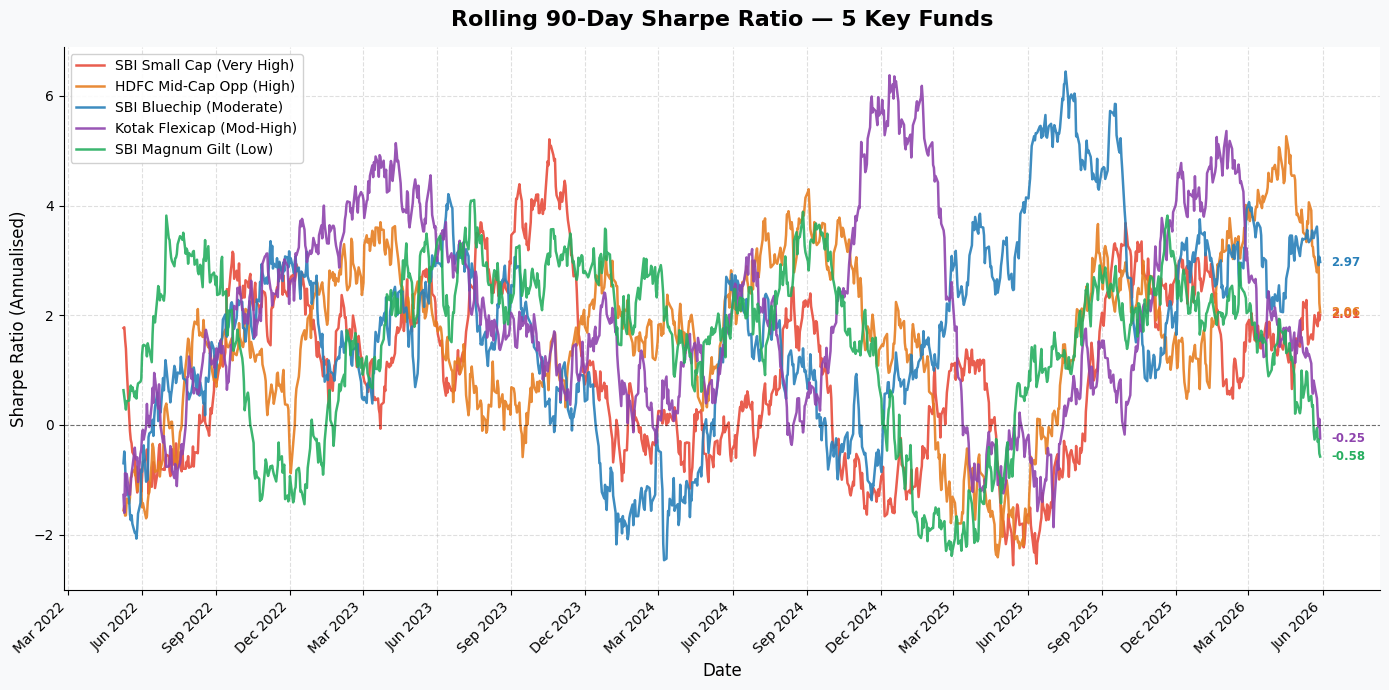

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

nav = pd.read_csv('data/raw/02_nav_history.csv')
master = pd.read_csv('data/raw/01_fund_master.csv')

nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

FIVE_FUNDS = {
    119598: 'SBI Small Cap (Very High)',
    100033: 'HDFC Mid-Cap Opp (High)',
    119551: 'SBI Bluechip (Moderate)',
    120843: 'Kotak Flexicap (Mod-High)',
    119120: 'SBI Magnum Gilt (Low)',
}

WINDOW = 90
ANNUALIZ = np.sqrt(252)

sharpe_dict = {}
for code, label in FIVE_FUNDS.items():
    grp = nav[nav['amfi_code'] == code][['date', 'daily_return']].dropna()
    grp = grp.set_index('date').sort_index()
    roll_mean = grp['daily_return'].rolling(WINDOW).mean()
    roll_std = grp['daily_return'].rolling(WINDOW).std()
    sharpe = (roll_mean / roll_std) * ANNUALIZ
    sharpe_dict[label] = sharpe

df_sharpe = pd.DataFrame(sharpe_dict).dropna(how='all')

COLORS = {
    'SBI Small Cap (Very High)': '#E74C3C',
    'HDFC Mid-Cap Opp (High)': '#E67E22',
    'SBI Bluechip (Moderate)': '#2980B9',
    'Kotak Flexicap (Mod-High)': '#8E44AD',
    'SBI Magnum Gilt (Low)': '#27AE60',
}

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

for label, color in COLORS.items():
    ax.plot(df_sharpe.index, df_sharpe[label], label=label, color=color, linewidth=1.8, alpha=0.9)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Rolling 90-Day Sharpe Ratio — 5 Key Funds', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sharpe Ratio (Annualised)', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

for label, color in COLORS.items():
    last_val = df_sharpe[label].dropna().iloc[-1]
    last_date = df_sharpe[label].dropna().index[-1]
    ax.annotate(f'{last_val:.2f}', xy=(last_date, last_val), xytext=(8, 0), textcoords='offset points', color=color, fontsize=8.5, fontweight='bold', va='center')

plt.tight_layout()
plt.savefig('reports/rolling_sharpe_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
import pandas as pd

df = pd.read_csv('data/raw/08_investor_transactions.csv')
master = pd.read_csv('data/raw/01_fund_master.csv')

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

first_tx = df.groupby('investor_id')['transaction_date'].min().dt.year.rename('cohort_year')
df = df.merge(first_tx, on='investor_id', how='left')

sip = df[df['transaction_type'] == 'SIP']

avg_sip = sip.groupby('cohort_year')['amount_inr'].mean().round(2).rename('avg_sip_amount')

total_invested = df.groupby('cohort_year')['amount_inr'].sum().rename('total_invested')

fav = sip.groupby(['cohort_year', 'amfi_code']).size().reset_index(name='count')
fav = fav.loc[fav.groupby('cohort_year')['count'].idxmax(), ['cohort_year', 'amfi_code']]
name_map = master[['amfi_code', 'scheme_name']].drop_duplicates()
fav = fav.merge(name_map, on='amfi_code', how='left').rename(columns={'scheme_name': 'top_fund'})
fav = fav[['cohort_year', 'top_fund']]

result = pd.concat([avg_sip, total_invested], axis=1).reset_index()
result = result.merge(fav, on='cohort_year', how='left')

print(result.to_string(index=False))

 cohort_year  avg_sip_amount  total_invested                                  top_fund
        2024        10996.89      3491125187 ICICI Pru Bluechip Fund - Direct - Growth
        2025        13505.21        30455243 SBI Small Cap Fund - Direct Plan - Growth


In [5]:
import pandas as pd

df = pd.read_csv('data/raw/08_investor_transactions.csv')

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

sip = df[df['transaction_type'] == 'SIP'].copy()

sip = sip.sort_values(['investor_id', 'transaction_date'])

sip_counts = sip.groupby('investor_id').size()
eligible = sip_counts[sip_counts >= 6].index
sip = sip[sip['investor_id'].isin(eligible)]

sip['prev_date'] = sip.groupby('investor_id')['transaction_date'].shift(1)
sip['gap_days'] = (sip['transaction_date'] - sip['prev_date']).dt.days
sip = sip.dropna(subset=['gap_days'])

investor_stats = sip.groupby('investor_id').agg(
    total_sip_count  = ('transaction_date', 'count'),
    avg_gap_days     = ('gap_days', 'mean'),
    max_gap_days     = ('gap_days', 'max'),
    total_invested   = ('amount_inr', 'sum'),
    avg_sip_amount   = ('amount_inr', 'mean'),
).round(2).reset_index()

investor_stats['status'] = investor_stats['avg_gap_days'].apply(
    lambda x: 'at-risk' if x > 35 else 'regular'
)

print("✅ Total eligible investors (6+ SIPs):", len(investor_stats))
print("🔴 At-risk investors           :", (investor_stats['status'] == 'at-risk').sum())
print("🟢 Regular investors           :", (investor_stats['status'] == 'regular').sum())
print()
print(investor_stats.head(10).to_string(index=False))

investor_stats.to_csv('reports/sip_continuity_report.csv', index=False)
print("\n✅ Saved → reports/sip_continuity_report.csv")

✅ Total eligible investors (6+ SIPs): 1362
🔴 At-risk investors           : 1332
🟢 Regular investors           : 30

investor_id  total_sip_count  avg_gap_days  max_gap_days  total_invested  avg_sip_amount  status
  INV000004                5         85.40         265.0           47296         9459.20 at-risk
  INV000008                5         70.40         165.0           64792        12958.40 at-risk
  INV000010                5         64.80         139.0           29328         5865.60 at-risk
  INV000011                6         40.17         125.0           91690        15281.67 at-risk
  INV000012                7         57.00         132.0           34586         4940.86 at-risk
  INV000013                6         55.33         104.0           71437        11906.17 at-risk
  INV000014                6         75.33         128.0          134958        22493.00 at-risk
  INV000023                7         58.57         115.0          185160        26451.43 at-risk
  INV000028

In [6]:
import pandas as pd

perf   = pd.read_csv('data/raw/07_scheme_performance.csv')
master = pd.read_csv('data/raw/01_fund_master.csv')

RISK_MAP = {
    'low'      : 'Low',
    'moderate' : 'Moderate',
    'high'     : 'High',
}

def recommend_funds(risk_appetite: str) -> pd.DataFrame:
    key = risk_appetite.strip().lower()

    if key not in RISK_MAP:
        print("❌ Invalid input! Choose from: Low / Moderate / High")
        return pd.DataFrame()

    risk_grade = RISK_MAP[key]

    filtered = perf[perf['risk_grade'] == risk_grade].copy()

    top3 = (filtered
            .sort_values('sharpe_ratio', ascending=False)
            .head(3)
            [['scheme_name', 'fund_house', 'category',
              'sharpe_ratio', 'return_1yr_pct', 'return_3yr_pct',
              'risk_grade', 'expense_ratio_pct', 'morningstar_rating']]
            .reset_index(drop=True))

    top3.index += 1

    print(f"\n✅ Top 3 Funds for Risk Appetite: {risk_grade}\n")
    print(top3.to_string())
    return top3

user_input = input("\nEnter risk appetite (Low / Moderate / High): ")
result = recommend_funds(user_input)


Enter risk appetite (Low / Moderate / High):  High



✅ Top 3 Funds for Risk Appetite: High

                                     scheme_name           fund_house category  sharpe_ratio  return_1yr_pct  return_3yr_pct risk_grade  expense_ratio_pct  morningstar_rating
1  Kotak Emerging Equity Fund - Regular - Growth    Kotak Mahindra MF  Mid Cap          0.96           17.12           18.23       High               1.56                   4
2       ICICI Pru Midcap Fund - Regular - Growth  ICICI Prudential MF  Mid Cap          0.95           14.02           18.08       High               1.36                   3
3             DSP Midcap Fund - Regular - Growth      DSP Mutual Fund  Mid Cap          0.90           14.12           17.16       High               1.61                   4


In [7]:
import pandas as pd

holdings = pd.read_csv('data/raw/09_portfolio_holdings.csv')
master   = pd.read_csv('data/raw/01_fund_master.csv')

equity_codes = master[master['category'] == 'Equity']['amfi_code'].unique()
equity_holdings = holdings[holdings['amfi_code'].isin(equity_codes)].copy()

sector_weights = (equity_holdings
                  .groupby(['amfi_code', 'sector'])['weight_pct']
                  .sum()
                  .reset_index())

sector_weights['weight_sq'] = sector_weights['weight_pct'] ** 2

hhi = (sector_weights
       .groupby('amfi_code')['weight_sq']
       .sum()
       .reset_index()
       .rename(columns={'weight_sq': 'HHI'}))

hhi['HHI'] = hhi['HHI'].round(2)

name_map = master[['amfi_code', 'scheme_name', 'category']].drop_duplicates('amfi_code')
hhi = hhi.merge(name_map, on='amfi_code', how='left')

hhi['concentration_level'] = hhi['HHI'].apply(
    lambda x: 'High' if x >= 2500 else ('Moderate' if x >= 1500 else 'Low')
)

hhi = hhi.sort_values('HHI', ascending=False).reset_index(drop=True)
hhi.index += 1

hhi = hhi[['amfi_code', 'scheme_name', 'category', 'HHI', 'concentration_level']]

print("✅ Sector HHI computed for", len(hhi), "equity funds\n")
print(hhi.to_string())

hhi.to_csv('reports/sector_hhi_report.csv', index=False)
print("\n✅ Saved → reports/sector_hhi_report.csv")

✅ Sector HHI computed for 34 equity funds

    amfi_code                                            scheme_name category      HHI concentration_level
1      119092                  Axis Bluechip Fund - Regular - Growth   Equity  2967.69                High
2      148569          Mirae Asset Tax Saver Fund - Regular - Growth   Equity  2549.92                High
3      125498      HDFC Mid-Cap Opportunities Fund - Direct - Growth   Equity  2531.55                High
4      102887                  UTI Flexi Cap Fund - Regular - Growth   Equity  2513.83                High
5      149323                     DSP Midcap Fund - Regular - Growth   Equity  2410.77            Moderate
6      120505               ICICI Pru Midcap Fund - Regular - Growth   Equity  2386.95            Moderate
7      118635                         Nippon India ETF Nifty 50 BeES   Equity  2374.97            Moderate
8      119599              SBI Small Cap Fund - Direct Plan - Growth   Equity  2323.61            Mod

In [8]:
import pandas as pd
import numpy as np
from IPython.display import Markdown, display

var_df      = pd.read_csv('reports/var_cvar_report.csv')
sip_df      = pd.read_csv('reports/sip_continuity_report.csv')
hhi_df      = pd.read_csv('reports/sector_hhi_report.csv')
txn_df      = pd.read_csv('data/raw/08_investor_transactions.csv')
perf_df     = pd.read_csv('data/raw/07_scheme_performance.csv')


top_var = var_df.nsmallest(3, 'VaR_95_pct')[['scheme_name','VaR_95_pct','CVaR_95_pct']]


txn_df['transaction_date'] = pd.to_datetime(txn_df['transaction_date'])
first_tx = txn_df.groupby('investor_id')['transaction_date'].min().dt.year.rename('cohort_year')
txn_df   = txn_df.merge(first_tx, on='investor_id', how='left')
cohort   = txn_df.groupby('cohort_year')['amount_inr'].sum().reset_index()
top_cohort      = cohort.loc[cohort['amount_inr'].idxmax()]
top_cohort_year = int(top_cohort['cohort_year'])
top_cohort_amt  = round(top_cohort['amount_inr'] / 1e7, 2)


total_investors   = len(sip_df)
atrisk_investors  = (sip_df['status'] == 'at-risk').sum()
regular_investors = (sip_df['status'] == 'regular').sum()
continuity_rate   = round((regular_investors / total_investors) * 100, 2)


most_conc = hhi_df.iloc[0]


best_sharpe = perf_df.loc[perf_df['sharpe_ratio'].idxmax()]



display(Markdown(f"""
---


Value at Risk (95%) measures the worst expected daily loss under normal market conditions.

| Fund | VaR 95% | CVaR 95% |
|------|---------|----------|
| {top_var.iloc[0]['scheme_name']} | {top_var.iloc[0]['VaR_95_pct']}% | {top_var.iloc[0]['CVaR_95_pct']}% |
| {top_var.iloc[1]['scheme_name']} | {top_var.iloc[1]['VaR_95_pct']}% | {top_var.iloc[1]['CVaR_95_pct']}% |
| {top_var.iloc[2]['scheme_name']} | {top_var.iloc[2]['VaR_95_pct']}% | {top_var.iloc[2]['CVaR_95_pct']}% |

> **Key Finding:** Small Cap and Mid Cap funds show the highest VaR, confirming higher downside risk compared to Large Cap or Debt funds.

---



Investors are grouped by the year of their first transaction (cohort year).

- **Top Cohort Year:** {top_cohort_year}
- **Total Amount Invested:** ₹{top_cohort_amt} Cr

> **Key Finding:** The {top_cohort_year} cohort dominates total investment volume, indicating strong market participation in that period.

---


SIP continuity measures how consistently investors maintain their monthly SIP schedule (gap threshold: 35 days).

| Metric | Value |
|--------|-------|
| Total Eligible Investors (6+ SIPs) | {total_investors} |
| Regular Investors (gap ≤ 35 days) | {regular_investors} |
| At-Risk Investors (gap > 35 days)  | {atrisk_investors} |
| **Continuity Rate**                | **{continuity_rate}%** |

> **Key Finding:** Only {continuity_rate}% investors maintain regular SIP cadence. High at-risk ratio reflects irregular investment behavior in the dataset period (2024–2025).

---

### 🏗️ Insight 4 — Most Concentrated Equity Fund (Sector HHI)

Herfindahl-Hirschman Index (HHI) measures portfolio concentration. Higher HHI = more concentrated in fewer sectors.

- **Most Concentrated Fund:** {most_conc['scheme_name']}
- **HHI Score:** {most_conc['HHI']}
- **Concentration Level:** {most_conc['concentration_level']}

> **Key Finding:** An HHI above 2500 indicates heavy sector concentration, meaning this fund's returns are highly sensitive to performance of 1–2 sectors.

---


Sharpe Ratio measures return earned per unit of risk taken. Higher is better.

- **Best Fund:** {best_sharpe['scheme_name']}
- **Sharpe Ratio:** {round(best_sharpe['sharpe_ratio'], 2)}
- **1-Year Return:** {best_sharpe['return_1yr_pct']}%
- **Risk Grade:** {best_sharpe['risk_grade']}

> **Key Finding:** This fund delivers the highest risk-adjusted return in the dataset, making it the most efficient fund for investors seeking optimal return per unit of risk.

---
"""))


---


Value at Risk (95%) measures the worst expected daily loss under normal market conditions.

| Fund | VaR 95% | CVaR 95% |
|------|---------|----------|
| SBI Small Cap Fund - Direct Plan - Growth | -2.6859% | -3.2384% |
| Axis Small Cap Fund - Regular - Growth | -2.6188% | -3.1667% |
| ABSL Small Cap Fund - Regular - Growth | -2.6021% | -3.2459% |

> **Key Finding:** Small Cap and Mid Cap funds show the highest VaR, confirming higher downside risk compared to Large Cap or Debt funds.

---



Investors are grouped by the year of their first transaction (cohort year).

- **Top Cohort Year:** 2024
- **Total Amount Invested:** ₹349.11 Cr

> **Key Finding:** The 2024 cohort dominates total investment volume, indicating strong market participation in that period.

---


SIP continuity measures how consistently investors maintain their monthly SIP schedule (gap threshold: 35 days).

| Metric | Value |
|--------|-------|
| Total Eligible Investors (6+ SIPs) | 1362 |
| Regular Investors (gap ≤ 35 days) | 30 |
| At-Risk Investors (gap > 35 days)  | 1332 |
| **Continuity Rate**                | **2.2%** |

> **Key Finding:** Only 2.2% investors maintain regular SIP cadence. High at-risk ratio reflects irregular investment behavior in the dataset period (2024–2025).

---

### 🏗️ Insight 4 — Most Concentrated Equity Fund (Sector HHI)

Herfindahl-Hirschman Index (HHI) measures portfolio concentration. Higher HHI = more concentrated in fewer sectors.

- **Most Concentrated Fund:** Axis Bluechip Fund - Regular - Growth
- **HHI Score:** 2967.69
- **Concentration Level:** High

> **Key Finding:** An HHI above 2500 indicates heavy sector concentration, meaning this fund's returns are highly sensitive to performance of 1–2 sectors.

---


Sharpe Ratio measures return earned per unit of risk taken. Higher is better.

- **Best Fund:** ICICI Pru Liquid Fund - Regular - Growth
- **Sharpe Ratio:** 7.68
- **1-Year Return:** 8.89%
- **Risk Grade:** Low

> **Key Finding:** This fund delivers the highest risk-adjusted return in the dataset, making it the most efficient fund for investors seeking optimal return per unit of risk.

---
